In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/nasa-turbofan-engine-degradation-simulation/RUL_FD002.txt
/kaggle/input/nasa-turbofan-engine-degradation-simulation/test_FD003.txt
/kaggle/input/nasa-turbofan-engine-degradation-simulation/Damage Propagation Modeling.pdf
/kaggle/input/nasa-turbofan-engine-degradation-simulation/readme.txt
/kaggle/input/nasa-turbofan-engine-degradation-simulation/train_FD003.txt
/kaggle/input/nasa-turbofan-engine-degradation-simulation/test_FD004.txt
/kaggle/input/nasa-turbofan-engine-degradation-simulation/train_FD004.txt
/kaggle/input/nasa-turbofan-engine-degradation-simulation/test_FD002.txt
/kaggle/input/nasa-turbofan-engine-degradation-simulation/train_FD001.txt
/kaggle/input/nasa-turbofan-engine-degradation-simulation/train_FD002.txt
/kaggle/input/nasa-turbofan-engine-degradation-simulation/RUL_FD001.txt
/kaggle/input/nasa-turbofan-engine-degradation-simulation/RUL_FD004.txt
/kaggle/input/nasa-turbofan-engine-degradation-simulation/RUL_FD003.txt
/kaggle/input/nasa-turbofan-engine-deg

## Project Overview: Predicting Remaining Useful Life (RUL) of Turbofan Engines

This project focuses on building a Predictive Maintenance system that estimates the **Remaining Useful Life (RUL)** of turbofan jet engines using multivariate time-series sensor data. The goal is to develop a robust machine learning pipeline that can anticipate engine failure before it happens, enabling proactive maintenance and reducing downtime.

To achieve this, we use NASA’s C-MAPSS Turbofan Engine Degradation Dataset, a widely recognized benchmark in aerospace and data science research. The dataset simulates realistic engine degradation under varying operational conditions, making it ideal for **RUL prediction**.


**About the Dataset:**

1. **train_FD001.txt** – Training Data
 - Multivariate time-series data from 100 simulated turbofan engines, each run until failure.
   
**Shape:** 20,631 rows × 26 columns

**Columns:**

unit_id: Unique engine identifier (1–100)

cycle: Operational cycle (discrete time step)

op_cond_1, op_cond_2, op_cond_3: Operating conditions

sensor_1 to sensor_21: Simulated sensor measurements

**RUL Handling:** The Remaining Useful Life (RUL) is not provided but deterministically computable as:


 2. **test_FD001.txt** – Test Data
**Description:** Time-series data from 100 different engines, each halted before failure (mimicking real-world inspection protocols).

**Shape:** 13,096 rows × 26 columns

**Structure:** Identical column schema to training data.
Objective:

**Predict** the RUL at the last recorded cycle for each engine — i.e., estimate how many additional operational cycles the engine could have completed before failure.

 3. **RUL_FD001.txt** – Ground Truth for Evaluation
**Description:** True Remaining Useful Life values for the 100 test engines.

**Shape:** 100 rows × 1 column (RUL)

- Exclusively for model evaluation (e.g., RMSE, NASA score). Not used during training or prediction.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
# from scipy.stats import ks_2samp, wasserstein_distance #finding the train-test distribution for modeling


In [3]:
cols = ['unit_id', 'cycle',
        'op_cond_1', 'op_cond_2', 'op_cond_3'] + \
       [f'sensor_{i}' for i in range(1, 22)]

In [4]:
rul_df = pd.read_csv('/kaggle/input/nasa-turbofan-engine-degradation-simulation/RUL_FD001.txt',sep = '\s+',header = None,names =['RUL'])
rul_df


,RUL
0,112
1,98
2,69
3,82
4,91
...,...
95,137
96,82
97,59
98,117


In [5]:
train_df = pd.read_csv('/kaggle/input/nasa-turbofan-engine-degradation-simulation/train_FD001.txt',sep = '\s+',header = None,names = cols)
train_df

,unit_id,cycle,op_cond_1,op_cond_2,op_cond_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640


In [6]:
train_df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   unit_id    20631 non-null  int64  
 1   cycle      20631 non-null  int64  
 2   op_cond_1  20631 non-null  float64
 3   op_cond_2  20631 non-null  float64
 4   op_cond_3  20631 non-null  float64
 5   sensor_1   20631 non-null  float64
 6   sensor_2   20631 non-null  float64
 7   sensor_3   20631 non-null  float64
 8   sensor_4   20631 non-null  float64
 9   sensor_5   20631 non-null  float64
 10  sensor_6   20631 non-null  float64
 11  sensor_7   20631 non-null  float64
 12  sensor_8   20631 non-null  float64
 13  sensor_9   20631 non-null  float64
 14  sensor_10  20631 non-null  float64
 15  sensor_11  20631 non-null  float64
 16  sensor_12  20631 non-null  float64
 17  sensor_13  20631 non-null  float64
 18  sensor_14  20631 non-null  float64
 19  sensor_15  20631 non-null  float64
 20  sensor

In [7]:
train_df.describe()

,unit_id,cycle,op_cond_1,op_cond_2,op_cond_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,2.063100e+04,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,5.186700e+02,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,6.537152e-11,0.500053,6.131150,9.000605,3.394700e-12,...,0.737553,0.071919,19.076176,0.037505,1.556432e-14,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,5.186700e+02,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,5.186700e+02,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,5.186700e+02,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,5.186700e+02,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,5.186700e+02,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


In [8]:
test_df = pd.read_csv('/kaggle/input/nasa-turbofan-engine-degradation-simulation/test_FD001.txt',sep = '\s+',header = None,names= cols)
test_df

,unit_id,cycle,op_cond_1,op_cond_2,op_cond_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13091,100,194,0.0049,0.0000,100.0,518.67,643.24,1599.45,1415.79,14.62,...,520.69,2388.00,8213.28,8.4715,0.03,394,2388,100.0,38.65,23.1974
13092,100,195,-0.0011,-0.0001,100.0,518.67,643.22,1595.69,1422.05,14.62,...,521.05,2388.09,8210.85,8.4512,0.03,395,2388,100.0,38.57,23.2771
13093,100,196,-0.0006,-0.0003,100.0,518.67,643.44,1593.15,1406.82,14.62,...,521.18,2388.04,8217.24,8.4569,0.03,395,2388,100.0,38.62,23.2051
13094,100,197,-0.0038,0.0001,100.0,518.67,643.26,1594.99,1419.36,14.62,...,521.33,2388.08,8220.48,8.4711,0.03,395,2388,100.0,38.66,23.2699


In [9]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13096 entries, 0 to 13095
Data columns (total 26 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   unit_id    13096 non-null  int64  
 1   cycle      13096 non-null  int64  
 2   op_cond_1  13096 non-null  float64
 3   op_cond_2  13096 non-null  float64
 4   op_cond_3  13096 non-null  float64
 5   sensor_1   13096 non-null  float64
 6   sensor_2   13096 non-null  float64
 7   sensor_3   13096 non-null  float64
 8   sensor_4   13096 non-null  float64
 9   sensor_5   13096 non-null  float64
 10  sensor_6   13096 non-null  float64
 11  sensor_7   13096 non-null  float64
 12  sensor_8   13096 non-null  float64
 13  sensor_9   13096 non-null  float64
 14  sensor_10  13096 non-null  float64
 15  sensor_11  13096 non-null  float64
 16  sensor_12  13096 non-null  float64
 17  sensor_13  13096 non-null  float64
 18  sensor_14  13096 non-null  float64
 19  sensor_15  13096 non-null  float64
 20  sensor

In [10]:
print("Train shape:", train_df.shape)   
print("Test shape:", test_df.shape)     
print("RUL shape:", rul_df.shape)       

print("\nFirst few rows of train data:")
train_df.head()

Train shape: (20631, 26)
Test shape: (13096, 26)
RUL shape: (100, 1)

First few rows of train data:


,unit_id,cycle,op_cond_1,op_cond_2,op_cond_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [11]:
print('Train_df NUll Val: ',train_df.isnull().sum().sum())
print('Test_df NUll Val: ',test_df.isnull().sum().sum())

Train_df NUll Val:  0
Test_df NUll Val:  0


## **Data Exploration**

In [12]:
dataset = {'Train Dataset': train_df,'Test Dataset':test_df,'RUL Dataset':rul_df}


In [13]:
for name, df in dataset.items():
    print("\n" + "*"*50)
    print(f"Summary Statistics: {name}")
    print("*"*50)
    print(df.describe().T)

    print('************** Missing Values *************** ')
    print('Missing Values in Dataset: ',df.isnull().sum().sum())
    print('\n************** Skewness Values *************** ')
    print("Skewness around Mean: ", df.skew())
    print('\n************** Checking Outliers Behaviour *************** ')
    print("Outliers extremity behavioure : ",df.kurt())
    print('\n************** Checking Variance Behaviour *************** ')
     #dropping the cols with zero-variance or close to zero 
    var = df.columns[df.var() <1e-12]
    print('Variance : ',var.tolist() if not var.empty else 'None')

for col in df.columns:
    fig_hist = px.histogram(
        df,
        x=col,
        nbins=50,
        title=f"{name} - Distribution of {col}",
        labels={'x': col, 'y': 'Frequency'}
    )
    fig_hist.update_traces(
        marker=dict(
            line=dict(
                color='black',
                width=0.8     
            )
        )
    )
    fig_hist.update_layout(showlegend=False)
    fig_hist.show()

    fig_box = px.box(
        df,
        x=col,
        title=f"{name} - Outliers in {col}",
        labels={'x': col}
    )
    fig_box.update_layout(showlegend=False)
    fig_box.show()
    



**************************************************
Summary Statistics: Train Dataset
**************************************************
             count         mean           std        min        25%  \
unit_id    20631.0    51.506568  2.922763e+01     1.0000    26.0000   
cycle      20631.0   108.807862  6.888099e+01     1.0000    52.0000   
op_cond_1  20631.0    -0.000009  2.187313e-03    -0.0087    -0.0015   
op_cond_2  20631.0     0.000002  2.930621e-04    -0.0006    -0.0002   
op_cond_3  20631.0   100.000000  0.000000e+00   100.0000   100.0000   
sensor_1   20631.0   518.670000  6.537152e-11   518.6700   518.6700   
sensor_2   20631.0   642.680934  5.000533e-01   641.2100   642.3250   
sensor_3   20631.0  1590.523119  6.131150e+00  1571.0400  1586.2600   
sensor_4   20631.0  1408.933782  9.000605e+00  1382.2500  1402.3600   
sensor_5   20631.0    14.620000  3.394700e-12    14.6200    14.6200   
sensor_6   20631.0    21.609803  1.388985e-03    21.6000    21.6100   
sensor_7   

## Summary
1. These variables carry no information for machine learning models. Their distributions in the test set also show zero variance.
   Variance :  ['op_cond_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19'] .Remove all zero-variance sensors.    Keeping them will not improve predictive power and will slow model training.

   Some sensors (e.g., sensor_8, sensor_12, sensor_13, sensor_21) vary only slightly.They may still contain degradation information, but models like LSTM need normalization to avoid numerical domination by large-variance sensors.
3. Sensors with extreme kurtosis like sensor_6 (train kurtosis ~45, test ~28) ,sensor_9 (train ~9.3, test ~7.5), sensor_14 (train ~8.8, test ~6.3). These are known in CMAPSS as “high-degradation sensors.These sensors carry real degradation signals but are noisy.They should NOT be removed, they are essential.

    However we can apply on them:
   - Rolling mean(smoothing)
   - proper scalling
   - careful validation, because outliers influence regression loss heavily.

4. As there is no missing data in our whole dataframe so we only focus on the areas of **Transformation** and **Scaling**!

## Covariate Shift

This code performs feature-wise train–test distribution diagnostics to detect covariate shift and extrapolation risk before model training.

In [14]:
report = {}
for col in train_df.columns:
    train_col = train_df[col]
    test_col = test_df[col]

    report[col] = {
        "Train Mean": train_col.mean(), #location shift
        "Test Mean": test_col.mean(),
        "Mean Difference": abs(train_col.mean() - test_col.mean()),

        "Train Std": train_col.std(), #scale shift
        "Test Std": test_col.std(),
        "Std Difference": abs(train_col.std() - test_col.std()),

        "Train Min": train_col.min(),
        "Test Min": test_col.min(),

        "Train Max": train_col.max(),
        "Test Max": test_col.max(),

        "Test Out of Train Range": ( #MinMax shift to detect the model extraplotation
            test_col.min() < train_col.min() or 
            test_col.max() > train_col.max()
        )
    }

simple_report_df = pd.DataFrame(report).T
simple_report_df

,Train Mean,Test Mean,Mean Difference,Train Std,Test Std,Std Difference,Train Min,Test Min,Train Max,Test Max,Test Out of Train Range
unit_id,51.506568,51.543907,0.037339,29.227633,28.289423,0.93821,1,1,100,100,False
cycle,108.807862,76.836515,31.971347,68.88099,53.057749,15.823241,1,1,362,303,False
op_cond_1,-0.000009,-0.000011,0.000002,0.002187,0.002203,0.000015,-0.0087,-0.0082,0.0087,0.0078,False
op_cond_2,0.000002,0.000004,0.000002,0.000293,0.000294,0.000001,-0.0006,-0.0006,0.0006,0.0007,True
op_cond_3,100.0,100.0,0.0,0.0,0.0,0.0,100.0,100.0,100.0,100.0,False
sensor_1,518.67,518.67,0.0,0.0,0.0,0.0,518.67,518.67,518.67,518.67,False
sensor_2,642.680934,642.475088,0.205846,0.500053,0.400899,0.099154,641.21,641.13,644.53,644.3,True
sensor_3,1590.523119,1588.099204,2.423914,6.13115,5.003274,1.127876,1571.04,1569.04,1616.91,1607.55,True
sensor_4,1408.933782,1404.735362,4.19842,9.000605,6.688309,2.312295,1382.25,1384.39,1441.49,1433.36,False
sensor_5,14.62,14.62,0.0,0.0,0.0,0.0,14.62,14.62,14.62,14.62,False


**Test Out of Train Range = True**
The test data contains values that do NOT exist in the train data for that sensor.This is called **covariate shift**, and it is one of the biggest reasons NASA RUL models fail.

In [15]:

output_dir = "/kaggle/working/distribution_plots_html"
os.makedirs(output_dir, exist_ok=True)

def compare_plot(col_name):
    train_col = train_df[col_name]
    test_col = test_df[col_name]

    fig = go.Figure()

    # Train distribution
    fig.add_trace(go.Histogram(
        x=train_col,
        name="Train",
        opacity=0.6
    ))

    # Test distribution
    fig.add_trace(go.Histogram(
        x=test_col,
        name="Test",
        opacity=0.6
    ))

    fig.update_layout(
        title=f"Train vs Test Distribution: {col_name}",
        barmode="overlay",
        xaxis_title=col_name,
        yaxis_title="Count"
    )

    file_path = os.path.join(
        output_dir,
        f"{col_name}_train_vs_test.html"
    )
    fig.write_html(file_path)

    fig.show()

for col in train_df.columns:
    compare_plot(col)


Several sensors have visible distribution drift between train and test:

- cycle: mean ~108 in train vs ~76 in test
The test engines operate for fewer cycles → this affects RUL distribution and requires careful label construction.

- sensor_3, sensor_4, sensor_7, sensor_8, sensor_9, sensor_14
These sensors show different means, ranges, and tails between train and test.

- skewness: train has strong skew in sensor_9 (2.55) vs test (1.65), same for sensor_14 (2.37 vs 1.35).
This confirms non-identical distributions, meaning models must be regularized or normalized properly.

This mismatch can cause poor generalization, especially in tree models and neural networks.
You will need scaling per sensor, and possibly operating-condition normalization.

## Next  Techniques to Implement:
 Several sensors never change , remove them.

- Some sensors shift between train and test .Will **apply scaling per sensor**.

- A few sensors show strong degradation behavior but also heavy outliers.We will Keep them but **smooth their patterns during feature engineering**.

- Cycle lengths differ. Will Create **RUL labels** correctly and avoid leakage.

- No missing values . Preprocessing is straightforward.

This EDA shows that **feature engineering** and **scaling** will be the most important parts of our RUL pipeline.

## **Techniques:**
1. Data Cleaning
2. Feature Engineering
3. Dimensionality Reduction Techniques
4. Modeling Techniques
5. Model Evaluation Techniques
6. Model Interpretation Techniques

Furthur detail would be discused with each step also ...

## FEATURE ENGINEERING

1. **Calculating the RUL**

In [16]:
max_cycle_df = (train_df.groupby('unit_id')['cycle'].max().reset_index().rename(columns = {'cycle':'max_cycle'}))
max_cycle_df

,unit_id,max_cycle
0,1,192
1,2,287
2,3,179
3,4,189
4,5,269
...,...,...
95,96,336
96,97,202
97,98,156
98,99,185


In [17]:
train_df.drop(columns = ['max_cycle_x','max_cycle_y','max_cycle','RUL'],inplace = True,errors = 'ignore')

In [18]:
train_df

,unit_id,cycle,op_cond_1,op_cond_2,op_cond_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640


In [19]:
if 'RUL' not in train_df.columns:
    max_cycle_df = train_df.groupby('unit_id')['cycle'].max().reset_index().rename(columns = {'cycle':'max_cycle'})

train_df = train_df.merge(max_cycle_df,on = 'unit_id',how = 'left')
train_df['RUL'] = train_df['max_cycle'] - train_df['cycle']
train_df.drop(columns = ['max_cycle'],inplace = True)

**2. Capping the RUL(Winsorization)**

RUL capping deliberately collapses the “healthy” region into a single label to prevent noise-fitting and force the model to learn degradation dynamics where sensor information actually exists

In [20]:
RUL_Cap = 125 #baseline threshold
train_df['RUL_Capped'] = train_df['RUL'].clip(upper = RUL_Cap)

# RUL_Cap = 125 that means healthy RUL_Cap = 0 that means failure and if ranges b/w 0 to 125 then distance to failure
#the target variabe is now RUL_Cap

<Axes: >

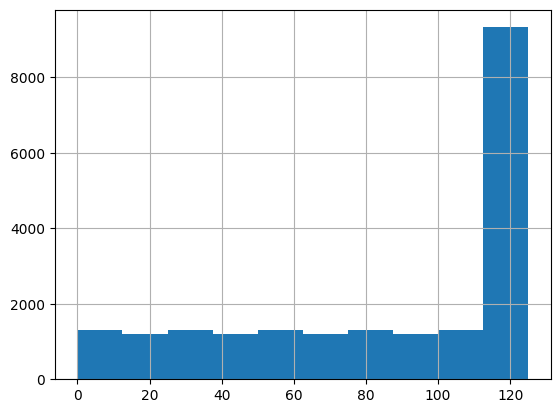

In [21]:
train_df['RUL_Capped'].hist()

**3. Removing Constant Sensors**

removing useless columns to reduce noise/dimensionality.

In [22]:
sensor_cols = [s for s in train_df.columns if s.startswith('sensor_')]

#dropping based on variance and keeping useful sensors
stds = train_df[sensor_cols].std()
low_Var = stds[stds < 1e-3].index.tolist()
print('Non-Useful Feature: ',low_Var)

useful_sensors = [c for c in sensor_cols if c not in low_Var]
print('\nUseful_ Features: ',useful_sensors)

#final data frame
train_df = train_df[['unit_id','cycle','RUL_Capped'] + useful_sensors + [c for c in train_df.columns if c.startswith('op_cond_')]]
test_df = test_df[['unit_id','cycle'] +  useful_sensors + [c for c in test_df.columns if c.startswith('op_cond_')]]

Non-Useful Feature:  ['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']

Useful_ Features:  ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [23]:
test_df

,unit_id,cycle,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,op_cond_1,op_cond_2,op_cond_3
0,1,1,643.02,1585.29,1398.21,21.61,553.90,2388.04,9050.17,47.20,521.72,2388.03,8125.55,8.4052,392,38.86,23.3735,0.0023,0.0003,100.0
1,1,2,641.71,1588.45,1395.42,21.61,554.85,2388.01,9054.42,47.50,522.16,2388.06,8139.62,8.3803,393,39.02,23.3916,-0.0027,-0.0003,100.0
2,1,3,642.46,1586.94,1401.34,21.61,554.11,2388.05,9056.96,47.50,521.97,2388.03,8130.10,8.4441,393,39.08,23.4166,0.0003,0.0001,100.0
3,1,4,642.44,1584.12,1406.42,21.61,554.07,2388.03,9045.29,47.28,521.38,2388.05,8132.90,8.3917,391,39.00,23.3737,0.0042,0.0000,100.0
4,1,5,642.51,1587.19,1401.92,21.61,554.16,2388.01,9044.55,47.31,522.15,2388.03,8129.54,8.4031,390,38.99,23.4130,0.0014,0.0000,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13091,100,194,643.24,1599.45,1415.79,21.61,553.41,2388.02,9142.37,47.69,520.69,2388.00,8213.28,8.4715,394,38.65,23.1974,0.0049,0.0000,100.0
13092,100,195,643.22,1595.69,1422.05,21.61,553.22,2388.05,9140.68,47.60,521.05,2388.09,8210.85,8.4512,395,38.57,23.2771,-0.0011,-0.0001,100.0
13093,100,196,643.44,1593.15,1406.82,21.61,553.04,2388.11,9146.81,47.57,521.18,2388.04,8217.24,8.4569,395,38.62,23.2051,-0.0006,-0.0003,100.0
13094,100,197,643.26,1594.99,1419.36,21.61,553.37,2388.07,9148.85,47.61,521.33,2388.08,8220.48,8.4711,395,38.66,23.2699,-0.0038,0.0001,100.0


**Normalization:**

CMAPSS uses operating settings that change distributions; normalize per regime or include ops as features. I'll show clustering into regimes then scale per regime (robust).

In [24]:
train_df_op = [c for c in train_df.columns if c.startswith('op_')]
print(train_df[train_df_op].nunique())

#as each operational different condition gives different RUL prediction so we have to cluster it

op_cond_1    158
op_cond_2     13
op_cond_3      1
dtype: int64


In [25]:
from sklearn.cluster import KMeans
if train_df_op:
    kmeans = KMeans(n_clusters = 6,random_state = 42)
    train_df['op_clusters']  = kmeans.fit_predict(train_df[train_df_op])
    test_df['op_clusters'] = kmeans.predict(test_df[train_df_op])
else:
    train_df['op_clusters'] = 0
    test_df['op_clusters'] = 0

This code applies **unsupervised KMeans clustering** to the CMAPSS operating condition variables in order to **identify latent operating regimes** under which aircraft engines run. Because sensor readings in CMAPSS are strongly influenced by operating conditions (such as altitude and throttle), the same sensor value can represent different health states across regimes. By clustering the operating conditions using only training data and assigning each record an `op_cluster`, the model is explicitly informed of the regime context in which the data was generated. This separation prevents the RUL model from confusing operational variability with degradation, preserves monotonic degradation patterns, and significantly improves generalization and stability. In short, this unsupervised step is critical because operating regimes are unlabeled, yet ignoring them leads to biased learning and degraded RUL performance.


In [26]:
train_df.head()

,unit_id,cycle,RUL_Capped,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,...,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,op_cond_1,op_cond_2,op_cond_3,op_clusters
0,1,1,125,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,...,2388.02,8138.62,8.4195,392,39.06,23.4190,-0.0007,-0.0004,100.0,3
1,1,2,125,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,...,2388.07,8131.49,8.4318,392,39.00,23.4236,0.0019,-0.0003,100.0,5
2,1,3,125,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,...,2388.03,8133.23,8.4178,390,38.95,23.3442,-0.0043,0.0003,100.0,4
3,1,4,125,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,...,2388.08,8133.83,8.3682,392,38.88,23.3739,0.0007,0.0000,100.0,1
4,1,5,125,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,...,2388.04,8133.80,8.4294,393,38.90,23.4044,-0.0019,-0.0002,100.0,0


In [27]:
fig = px.scatter(
    train_df,
    x='op_cond_1',
    y='op_cond_2',
    color='op_clusters',
    title='2D Scatter: Operating Condition Clusters',
    opacity=0.6
)

fig.show()

**Computing Rolling Statistics:**

Rolling statistics transform raw sensor time series into localized trend, variability, and extremal features computed per engine, enabling the RUL model to capture short-, medium-, and long-term degradation dynamics that single sensor readings cannot represent.

In [28]:
#capturing short term trend behaviour
WINDOWS = [5,10,15] #short,medium and high

for w in WINDOWS:
    for sensor in useful_sensors:
        col_mean = f'{sensor}_rmean_{w}'
        col_std = f'{sensor}_rstd_{w}'
        col_max = f'{sensor}_rmax_{w}'
        col_min = f'{sensor}_rmin_{w}'

        train_df[col_mean] = train_df.groupby('unit_id')[sensor].rolling(w,min_periods = 1).mean().reset_index(level =0 ,drop = True) #compute the current trend and compute the mean at each point
        #to check the variabilit of data 
        train_df[col_std] = train_df.groupby('unit_id')[sensor].rolling(w,min_periods = 1).std().reset_index(level =0 ,drop = True).fillna(0) #replace the non_changin values with 0
        train_df[col_max] = train_df.groupby('unit_id')[sensor].rolling(w,min_periods = 1).max().reset_index(level =0 ,drop = True)
        train_df[col_min] = train_df.groupby('unit_id')[sensor].rolling(w,min_periods = 1).min().reset_index(level =0 ,drop = True)

        #same for test
        test_df[col_mean] = test_df.groupby('unit_id')[sensor].rolling(w, min_periods=1).mean().reset_index(level=0, drop=True)
        test_df[col_std]  = test_df.groupby('unit_id')[sensor].rolling(w, min_periods=1).std().reset_index(level=0, drop=True).fillna(0)
        test_df[col_min]  = test_df.groupby('unit_id')[sensor].rolling(w, min_periods=1).min().reset_index(level=0, drop=True)
        test_df[col_max]  = test_df.groupby('unit_id')[sensor].rolling(w, min_periods=1).max().reset_index(level=0, drop=True)

In [29]:
train_df.head()

,unit_id,cycle,RUL_Capped,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,...,sensor_17_rmax_15,sensor_17_rmin_15,sensor_20_rmean_15,sensor_20_rstd_15,sensor_20_rmax_15,sensor_20_rmin_15,sensor_21_rmean_15,sensor_21_rstd_15,sensor_21_rmax_15,sensor_21_rmin_15
0,1,1,125,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,...,392.0,392.0,39.060000,0.000000,39.06,39.06,23.419000,0.000000,23.4190,23.4190
1,1,2,125,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,...,392.0,392.0,39.030000,0.042426,39.06,39.00,23.421300,0.003253,23.4236,23.4190
2,1,3,125,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,...,392.0,390.0,39.003333,0.055076,39.06,38.95,23.395600,0.044573,23.4236,23.3442
3,1,4,125,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,...,392.0,390.0,38.972500,0.076322,39.06,38.88,23.390175,0.037977,23.4236,23.3442
4,1,5,125,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,...,393.0,390.0,38.958000,0.073621,39.06,38.88,23.393020,0.033498,23.4236,23.3442


**Cyclic Normalization(Differences/Rate of Change)**

Cycle normalization encodes relative position in a sequence, while first differences encode rate and direction of change; together they provide temporal context and dynamics that raw values and rolling statistics cannot represent alone. Giving the sense to model to compare the early vs end stages of engine cycles in normalized and scaled way!

In [30]:
# adding cycle percent (position in life)
#Like if unit_id = 1 and max_cycle = 200 then dividing the that cycle to it's max cyclic value (1/100) = 0.01 normalized value
#0 means start,0.5 means mid, and 1 means end-life
train_df['cyclic_norm'] = train_df.groupby('unit_id')['cycle'].transform(lambda x: x/x.max())
test_df['cyclic_norm'] = test_df.groupby('unit_id')['cycle'].transform(lambda x: x/x.max())

#Calculating the difference to check the speed of variability and the direction of variability bcz a value could be high but stable but it can be low and fast changing
for cols in useful_sensors:
    dcols = f'{cols}_diff1'

    train_df[dcols] = train_df.groupby('unit_id')['cycle'].diff().fillna(0) #fillna(0) bcz 1st value has no previouse val so replacing NaN with 0
    test_df[dcols] = test_df.groupby('unit_id')['cycle'].diff().fillna(0)



In [31]:
train_df.head()


,unit_id,cycle,RUL_Capped,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,...,sensor_8_diff1,sensor_9_diff1,sensor_11_diff1,sensor_12_diff1,sensor_13_diff1,sensor_14_diff1,sensor_15_diff1,sensor_17_diff1,sensor_20_diff1,sensor_21_diff1
0,1,1,125,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,2,125,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,1,3,125,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,1,4,125,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,1,5,125,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [32]:
from sklearn.decomposition import PCA
pca_features = [
    col for col in train_df.columns
    if any(col.endswith(f'_rmean_{w}') for w in WINDOWS)
]
pca = PCA(n_components = 1)

#applying pca just on the rolling mean features bcz they are homogeniouse and that's why combining all of them into 1 component as they show the health of engine
train_df['health_index'] = pca.fit_transform(train_df[pca_features])
test_df['health_index'] = pca.fit_transform(test_df[pca_features])


In [33]:
train_df.head()

,unit_id,cycle,RUL_Capped,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,...,sensor_9_diff1,sensor_11_diff1,sensor_12_diff1,sensor_13_diff1,sensor_14_diff1,sensor_15_diff1,sensor_17_diff1,sensor_20_diff1,sensor_21_diff1,health_index
0,1,1,125,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-29.977529
1,1,2,125,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-35.067861
2,1,3,125,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-32.373920
3,1,4,125,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-32.198025
4,1,5,125,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-30.489116


In [34]:
fig = go.Figure()

for uid in train_df['unit_id'].unique()[:15]:
    unit_df = train_df[train_df['unit_id'] == uid]

    fig.add_trace(go.Scatter(
        x=unit_df['cycle'],
        y=unit_df['health_index'],
        mode='lines',
        line=dict(width=3),
        name=f'Unit {uid}'
    ))

fig.update_layout(
    title='Smoothed Health Index Degradation Trajectories',
    xaxis_title='Cycle',
    yaxis_title='Health Index (PC1)',
    template='plotly_white'
)

fig.show()

**Interpretation:**

The PCA-based health index exhibits consistent, monotonic degradation trajectories across multiple units, with a clear transition from healthy operation to accelerated degradation, confirming that the selected sensor features form a homogeneous set capturing a common latent failure mechanism.

Upward movement = degradation

Lower values = healthier state

End of life corresponds to the highest Health Index values

-------------------------------------------

In [35]:
test_df.head()

,unit_id,cycle,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,...,sensor_9_diff1,sensor_11_diff1,sensor_12_diff1,sensor_13_diff1,sensor_14_diff1,sensor_15_diff1,sensor_17_diff1,sensor_20_diff1,sensor_21_diff1,health_index
0,1,1,643.02,1585.29,1398.21,21.61,553.90,2388.04,9050.17,47.20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-25.246833
1,1,2,641.71,1588.45,1395.42,21.61,554.85,2388.01,9054.42,47.50,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-14.226903
2,1,3,642.46,1586.94,1401.34,21.61,554.11,2388.05,9056.96,47.50,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-13.302280
3,1,4,642.44,1584.12,1406.42,21.61,554.07,2388.03,9045.29,47.28,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-15.820430
4,1,5,642.51,1587.19,1401.92,21.61,554.16,2388.01,9044.55,47.31,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-18.250862


## Feature Selection

In [36]:
exclude_cols = ['unit_id','cycle','RUL','RUL_capped','op_cluster']  # keep op_cluster if using
all_features = [c for c in train_df.columns if c not in exclude_cols and not c.startswith('op_cond_')] #final features for modeling

**1. unit_id**
Removed because it is a unique identifier with no predictive meaning; including it would allow the model to memorize individual units rather than learn general patterns.

**2. cycle**
Removed because it is an absolute time index that is not comparable across sequences of different lengths and can create shortcut learning; relative or engineered time features are preferred.

**3. RUL**
Removed because it is the target variable itself; using it as a feature would cause direct label leakage.

**4. RUL_capped**
Removed because it is a transformed version of the target; any function of the target still leaks future information and invalidates the model.

***5. op_cond_*** (raw operating condition columns)
Removed because they describe external operating context rather than system health and can introduce spurious correlations; they are used for regime handling, not direct prediction.

**6. op_cluster**
Usually removed because it represents operating regime context rather than degradation state and may dominate learning if included blindly; only retained when explicitly validated as a conditioning feature.

These features are excluded because they either leak the target, enable memorization, encode non-comparable time information, or represent operating context rather than the underlying signal of interest, removing them ensures that the model learns generalizable and causally meaningful patterns.

-------------------

## MODELING PHASE 